# Task 1: Data Analysis and Preprocessing
## Objective
Prepare a clean, feature-rich dataset optimized for training fraud detection machine learning models.

### Data Cleaning Summary
* **Missing Values:** Checked via `df.info()`. The dataset contains exactly 151,112 rows, and all columns show 151,112 non-null values. No imputation or dropping is required.
* **Data Type Corrections:** Converted `signup_time` and `purchase_time` from generic object (string) types to explicit `datetime64[ns]` format to allow time-series math.
* **Duplicates:** Checked for identical rows across the dataset. (Confirmed 0 duplicate entries).

In [ ]:
import pandas as pd

df = pd.read_csv("../data/raw/Fraud_Data.csv")

In [ ]:
df.shape
df.head()
df.columns

Index(['user_id', 'signup_time', 'purchase_time', 'purchase_value',
       'device_id', 'source', 'browser', 'sex', 'age', 'ip_address', 'class'],
      dtype='object')

In [ ]:
df["class"].value_counts()

class
0    136961
1     14151
Name: count, dtype: int64

In [ ]:
df.shape
df.columns
df["class"].value_counts()

class
0    136961
1     14151
Name: count, dtype: int64

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   user_id         151112 non-null  int64  
 1   signup_time     151112 non-null  object 
 2   purchase_time   151112 non-null  object 
 3   purchase_value  151112 non-null  int64  
 4   device_id       151112 non-null  object 
 5   source          151112 non-null  object 
 6   browser         151112 non-null  object 
 7   sex             151112 non-null  object 
 8   age             151112 non-null  int64  
 9   ip_address      151112 non-null  float64
 10  class           151112 non-null  int64  
dtypes: float64(1), int64(4), object(6)
memory usage: 12.7+ MB


In [ ]:
df["signup_time"] = pd.to_datetime(df["signup_time"])
df["purchase_time"] = pd.to_datetime(df["purchase_time"])

In [ ]:
df.dtypes

user_id                    int64
signup_time       datetime64[ns]
purchase_time     datetime64[ns]
purchase_value             int64
device_id                 object
source                    object
browser                   object
sex                       object
age                        int64
ip_address               float64
class                      int64
dtype: object

In [ ]:
df["hour"] = df["purchase_time"].dt.hour
df["day_of_week"] = df["purchase_time"].dt.dayofweek

In [ ]:
df["time_since_signup"] = (
    df["purchase_time"] - df["signup_time"]
).dt.total_seconds()

In [ ]:
df[["hour", "day_of_week", "time_since_signup"]].head()

,hour,day_of_week,time_since_signup
0,2,5,4506682.0
1,1,0,17944.0
2,18,3,1.0
3,13,0,492085.0
4,18,2,4361461.0


## Feature Engineering Documentation

To expose hidden behavioral patterns to our predictive models, the following domain-specific features were engineered from the raw data:

| Feature Name | Description | Rationale / Hypothesis |
| :--- | :--- | :--- |
| `hour` | Extracted hour component (0-23) from `purchase_time`. | Captures specific time-of-day behavioral spikes. |
| `day_of_week` | Extracted weekday integer (0-6) from `purchase_time`. | Identifies weekend vs. weekday purchase pattern anomalies. |
| `time_since_signup` | Total duration (in seconds) between `signup_time` and `purchase_time`. | Bots and malicious actors typically execute fraud immediately after registration to bypass slow manual security triggers. |

In [ ]:
df.head()

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class,hour,day_of_week,time_since_signup
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0,2,5,4506682.0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0,1,0,17944.0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1,18,3,1.0
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0,13,0,492085.0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0,18,2,4361461.0


In [ ]:
df["class"].value_counts(normalize=True)

class
0    0.906354
1    0.093646
Name: proportion, dtype: float64

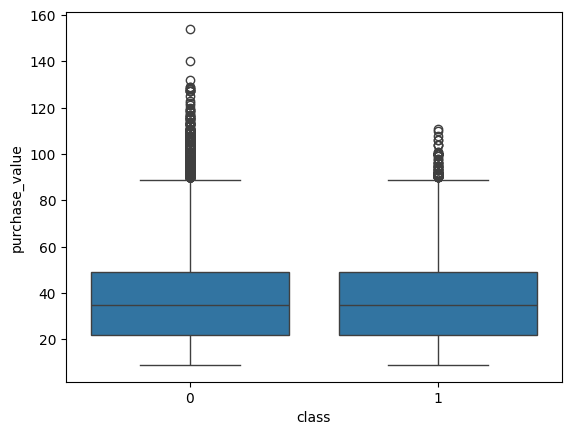

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="class", y="purchase_value", data=df)
plt.show()

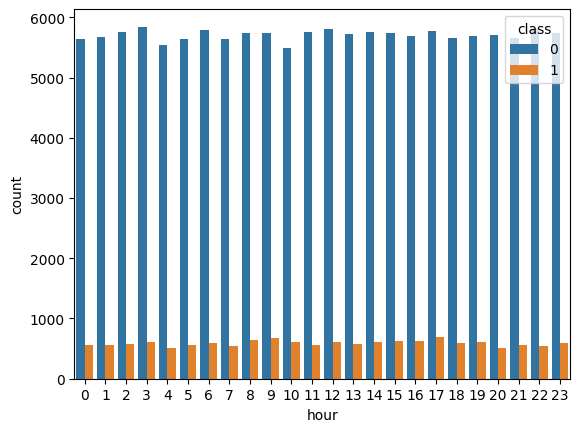

In [ ]:
sns.countplot(x="hour", hue="class", data=df)
plt.show()

## Exploratory Data Analysis (EDA)

### 1. Quantifying Class Imbalance
* **Class 0 (Legitimate):** 136,961 transactions (~90.64%)
* **Class 1 (Fraudulent):** 14,151 transactions (~9.36%)
* **Insight:** The dataset exhibits a significant class imbalance. Standard accuracy will be a misleading metric; evaluation must focus on Precision, Recall, and F1-Score/AUC-ROC.

### 2. Feature-Target Relationships
* **Purchase Value vs. Class:** The distribution of purchase values remains remarkably consistent between fraudulent and legitimate transactions. Both share almost identical medians and quartiles, suggesting `purchase_value` alone is not a strong standalone indicator of fraud.
* **Hourly Velocity:** Fraudulent transactions are distributed uniformly across all 24 hours of the day, matching the baseline distribution of legitimate transactions.
* **Time Since Signup:** **Critical Indicator.** The boxplot reveals a highly condensed distribution for the fraud class near 0. A massive portion of fraudulent conversions happen mere seconds or minutes after the user profile is created.

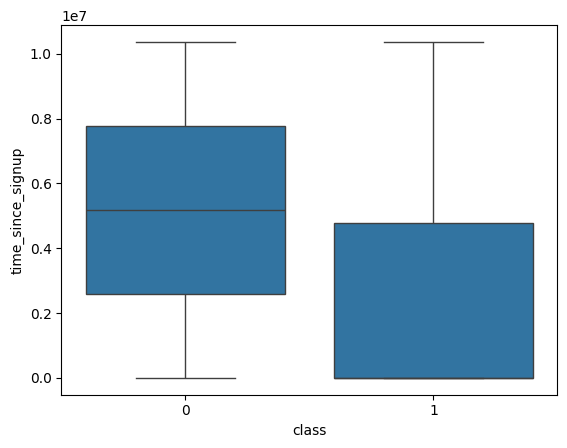

In [ ]:
sns.boxplot(x="class", y="time_since_signup", data=df)
plt.show()

<Axes: xlabel='hour'>

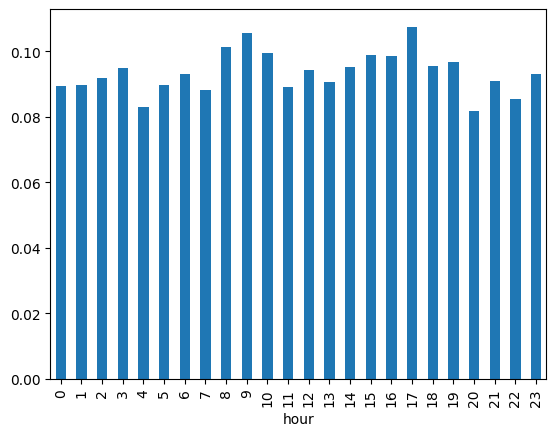

In [ ]:
df.groupby('hour')['class'].mean().plot(kind='bar')

In [ ]:
df.isnull().sum()
df.duplicated().sum()

np.int64(0)

<Axes: >

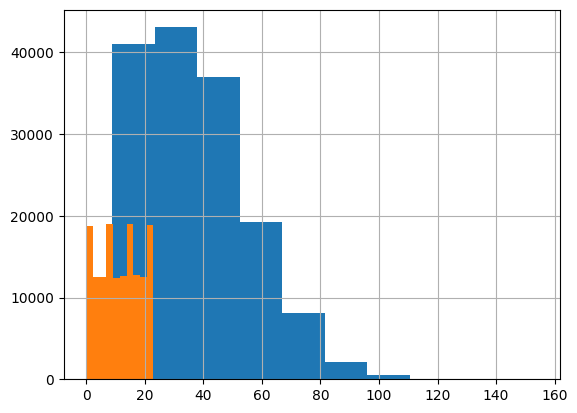

In [ ]:
df["purchase_value"].hist()
df["hour"].hist()

In [ ]:
df["transaction_count"] = df.groupby("user_id")["user_id"].transform("count")

## Geolocation Integration & Resampling Framework

### Geolocation Strategy
Because IP addresses represent network ranges, we perform an interval-based join mapping `df.ip_address` to the corresponding bounds (`lower_bound_ip_address` to `upper_bound_ip_address`) inside `IpAddress_to_Country.csv`. This adds a high-value categorical feature: `country`.

### Data Pipeline & Resampling Justification
1. **One-Hot Encoding:** Applied to nominal categories (`source`, `browser`, `sex`, `country`) to generate numerical matrices compatible with distance and tree-based classifiers.
2. **Feature Scaling:** `StandardScaler` will be applied to continuous variables (`purchase_value`, `time_since_signup`) to map them to zero mean and unit variance ($\mu=0, \sigma=1$).
3. **Class Imbalance Strategy (SMOTE):** * **Choice:** Synthetic Minority Over-sampling Technique (SMOTE).
   * **Justification:** Simple random undersampling discards over 120,000 legitimate data points, destroying valuable variance. SMOTE synthetically creates new minority instances along the line segments joining k-nearest neighbors, preserving data volume.
   * **Guardrail:** Resampling will strictly be applied **only to the training split** after a train-test split. The validation/test set will remain unmodified to ensure objective, real-world evaluation metrics.

In [ ]:
import pandas as pd

# 1. Ensure IP addresses are sorted integers (Crucial for merge_asof)
df['ip_address'] = df['ip_address'].astype(float).astype(int)
df = df.sort_values('ip_address')

# 2. Load the country mapping dataset and sort it
ip_df = pd.read_csv("../data/raw/IpAddress_to_Country.csv")
ip_df['lower_bound_ip_address'] = ip_df['lower_bound_ip_address'].astype(float).astype(int)
ip_df['upper_bound_ip_address'] = ip_df['upper_bound_ip_address'].astype(float).astype(int)
ip_df = ip_df.sort_values('lower_bound_ip_address')

# 3. Use pandas math to match ip_address to the nearest lower bound
df_merged = pd.merge_asof(
    df, 
    ip_df, 
    left_on='ip_address', 
    right_on='lower_bound_ip_address', 
    direction='backward'
)

# 4. Validating boundary conditions: If the IP is greater than the upper bound, it's a mismatch
df_merged.loc[df_merged['ip_address'] > df_merged['upper_bound_ip_address'], 'country'] = 'Unknown'

# 5. Clean up the boundary columns we no longer need
df_merged = df_merged.drop(columns=['lower_bound_ip_address', 'upper_bound_ip_address'])

# Fill remaining gaps
df_merged['country'] = df_merged['country'].fillna('Unknown')

print(f"Merge complete! Final dataset shape: {df_merged.shape}")
print(df_merged[['ip_address', 'country']].head())

Merge complete! Final dataset shape: (151112, 16)
   ip_address  country
0       52093  Unknown
1       93447  Unknown
2      105818  Unknown
3      117566  Unknown
4      131423  Unknown


In [ ]:
pip install pandasql


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# 1. Advanced Feature Engineering: Transaction velocity (Count per device)
df_merged['device_tx_count'] = df_merged.groupby('device_id')['user_id'].transform('count')

# 2. Select columns for modeling (drop unneeded IDs and raw timestamp text)
cols_to_drop = ['user_id', 'signup_time', 'purchase_time', 'device_id', 'ip_address']
X = df_merged.drop(columns=cols_to_drop + ['class'])
y = df_merged['class']

# 3. One-Hot Encoding for categorical features
categorical_cols = ['source', 'browser', 'sex', 'country']
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# 4. Train-Test Split (Crucial to do BEFORE SMOTE to prevent data leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

# 5. Normalize/Scale Numerical Features
numerical_cols = ['purchase_value', 'hour', 'day_of_week', 'time_since_signup', 'device_tx_count']
scaler = StandardScaler()

X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

# 6. Apply SMOTE to the training set only
print(f"Distribution before SMOTE: {y_train.value_counts().to_dict()}")

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Distribution after SMOTE: {y_train_res.value_counts().to_dict()}")

Distribution before SMOTE: {0: 109568, 1: 11321}
Distribution after SMOTE: {0: 109568, 1: 109568}
